<a href="https://colab.research.google.com/github/666fl/my-portfolio/blob/main/Licence_Plate_Recog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# import all the dependencies


In [ ]:
!pip install easyocr

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import easyocr
import imutils

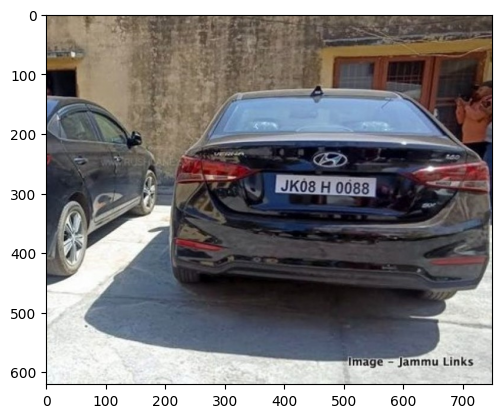

In [ ]:
img = cv2.imread('image1.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

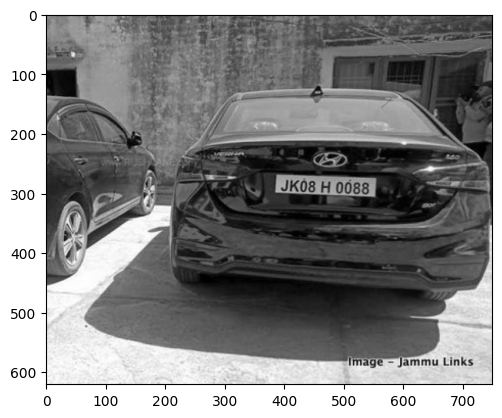

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))

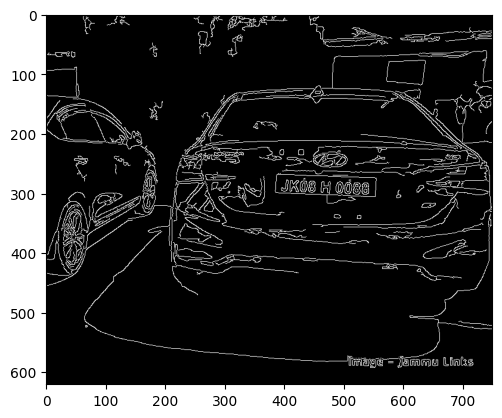

In [ ]:
fillered = cv2.bilateralFilter(gray, 10, 17, 17) #noise reduction
edged = cv2.Canny(fillered, 30, 200) #edge detection, canny's algorithm
plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

Find Contours aka edges and apply mask

In [ ]:
keypoints = cv2.findContours(edged.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = imutils.grab_contours(keypoints)
contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

In [ ]:
location = None
for contour in contours:
    approx = cv2.approxPolyDP(contour, 10, True)
    if (len(approx) == 4):
        location = approx
        break

In [ ]:
location

array([[[386, 271]],

       [[551, 274]],

       [[552, 305]],

       [[390, 300]]], dtype=int32)

In [ ]:
mask = np.zeros(gray.shape, np.uint8)
new_image = cv2.drawContours(mask, [location], 0, 255, -1)
new_image = cv2.bitwise_and(img, img, mask=mask)

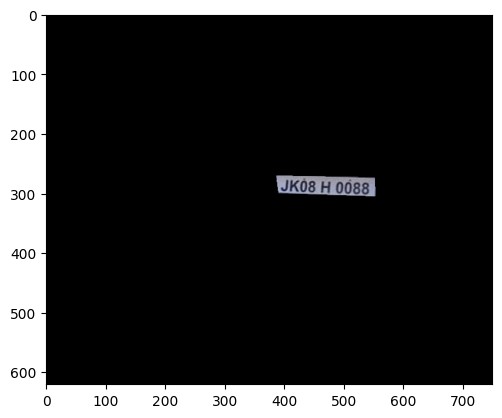

In [ ]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

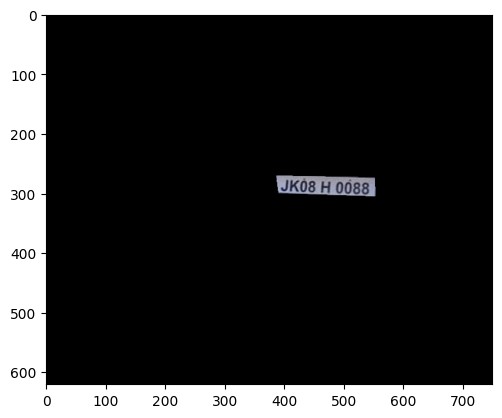

In [ ]:
plt.imshow(cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB))

In [ ]:
reader = easyocr.Reader(['en'])
result = reader.readtext(new_image)
text = result[0][1]

NameError: name 'easyocr' is not defined

In [ ]:
!pip install easyocr
import easyocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 kB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.2/307.2 kB 39.4 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manyl

In [ ]:
text

'JKO8 H 0088'

In [ ]:
import cv2
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)
res = cv2.rectangle(img, tuple(approx[0][0]), tuple(approx[2][0]), (0,255,0),3)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))

NameError: name 'text' is not defined

In [ ]:
# Load an image using OpenCV
img = cv2.imread('path/to/image.jpg')

# Check if the image is loaded properly
if img is None:
    raise ValueError("Error loading image")

# Use the `img` variable in the `cv2.putText` function
font = cv2.FONT_HERSHEY_SIMPLEX
res = cv2.putText(img, text=text, org=(approx[0][0][0], approx[1][0][1]+60), fontFace=font, fontScale=1, color=(0,255,0), thickness=2, lineType=cv2.LINE_AA)

# Show the result
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))

ValueError: Error loading image

In [ ]:
# Check if the image is loaded properly
if img is None:
    # Try loading the image using PIL
    try:
        from PIL import Image
        img = Image.open('image1.jpg')
        img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    except:
        raise ValueError("Error loading image")


ValueError: Error loading image

In [ ]:
!pip install opencv-python